# bGEV model for ozone level with stan

In [1]:
# Install cmdstanpy and arviz modules (just one time)
# !pip install cmdstanpy
# !pip install arviz
# !pip install pyreadr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 776.2/776.2 kB 32.1 MB/s eta 0:00:00


In [2]:
# Check if cmdstanpy and arviz are installed
!pip list | grep cmdstanpy
!pip list | grep arviz

cmdstanpy                                1.3.0
arviz                                    0.22.0


In [3]:
# Install cmdstan -- Just for the first time!
from cmdstanpy import install_cmdstan
install_cmdstan()

CmdStan install directory: /root/.cmdstan
Installing CmdStan version: 2.38.0
Download successful, file: /tmp/tmpo0d6rgbi
Extracting distribution
Unpacked download as cmdstan-2.38.0
Building version cmdstan-2.38.0, may take several minutes, depending on your system.
Installed cmdstan-2.38.0
Test model compilation


True

In [4]:
# You can then check the cmdstan path through this commands
from cmdstanpy import cmdstan_path
cmdstan_path()

'/root/.cmdstan/cmdstan-2.38.0'

In [5]:
# Create folder to store .stan files
import os
if not os.path.exists("./stan"):
    os.mkdir("./stan")

# Import modules
import numpy as np
import arviz as az
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Import functions
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions

# Import dataset

In [6]:
full_data = pd.read_csv('weekly_ozone_and_covariates.csv',sep=',')

In [7]:
# extract the year
full_data["week"] = full_data["week"].apply(lambda x: x.split('/')[0])
full_data["week"] = pd.to_datetime(full_data["week"])
full_data["year"] = full_data["week"].dt.year


In [8]:
sensors = np.unique(full_data['idSensor'].to_numpy())

selected_sensors = sensors[:3]
test_year = 2024

# keep the data for the selected sensors and year
data_training = full_data[full_data['idSensor'].isin(selected_sensors) & (full_data['year'] != test_year)]
data_test = full_data[full_data['idSensor'].isin(selected_sensors) & (full_data['year'] == test_year)]
data_training.shape, data_test.shape

((930, 8), (159, 8))

In [9]:
selected_sensors

array([5707, 5710, 5717])

In [ ]:
# normalize the columns in data
data_norm = data_training.copy()
data_norm["maxTemp"] = (data_norm["maxTemp"] - data_norm["maxTemp"].mean()) / data_norm["maxTemp"].std()
data_norm["minTemp"] = (data_norm["minTemp"] - data_norm["minTemp"].mean()) / data_norm["minTemp"].std()
data_norm["rainSum"] = (data_norm["rainSum"] - data_norm["rainSum"].mean()) / data_norm["rainSum"].std()
data_norm["windSpeed"] = (data_norm["windSpeed"] - data_norm["windSpeed"].mean()) / data_norm["windSpeed"].std()


In [ ]:
y = data_norm["maxOzone"].to_numpy()
X = data_norm[["maxTemp", "minTemp", "rainSum", "windSpeed"]].to_numpy()

# add intercept in X
X = np.hstack((np.ones((X.shape[0], 1)), X))

reg_data = {
    "N": len(y),
    "P": X.shape[1],
    "y": y,
    "X": X,
}

#  Stan model

In [13]:
bGEV_model = """functions {

	real ell(real p, real xi) {
		if (abs(xi) < 1e-6)
		  return log(-log(p));
		else
		  return pow(-log(p), -xi);
	 }

	 vector new_to_old(
		real q,
		real s,
		real xi,
		real alpha,
		real beta
	  ) {
		vector[2] out; // (mu, sigma)
		real ell1;
		real ell2;
		real ell3;
		real denom;

		ell1 = ell(alpha, xi);
		ell2 = ell(beta / 2, xi);
		ell3 = ell(1 - beta / 2, xi);
		denom = ell3 - ell2;

		if (abs(xi) < 1e-6) {
		  out[2] = s / denom;
		  out[1]    = q + out[2] * ell1;
		} else {
		  out[2] = xi * s / denom;
		  out[1]    = q - s * (ell1 - 1) / denom;
		}
		return out;
	}

	real gev_lpdf(real x, real mu, real sigma, real xi) {
		real z;
		real t;

		z = (x - mu) / sigma;

		// Gumbel limit
		if (abs(xi) < 1e-6) {
		  return -log(sigma)
				 - z
				 - exp(-z);
		}

		// General case
		t = 1 + xi * z;

		// Support condition
		if (t <= 0)
		  return negative_infinity();

		return -log(sigma)
			   - (1 + 1 / xi) * log(t)
			   - pow(t, -1 / xi);
	  }

	real gev_cdf(real x, real mu, real sigma, real xi) {
		real z;
		real t;

		z = (x - mu) / sigma;

		// Gumbel limit
		if (abs(xi) < 1e-6) {
		  return exp(-exp(-z));
		}

		// General GEV
		t = 1 + xi * z;

		// Support condition
		if (t <= 0)
		  return 0;

		return exp(-pow(t, -1 / xi));
	}

	real gev_quantile(real p, real mu, real sigma, real xi) {

		// Defensive programming (optional but recommended)
		if (p <= 0 || p >= 1)
		  reject("gev_quantile: p must be in (0,1)");

		// Gumbel limit
		if (abs(xi) < 1e-6) {
		  return mu - sigma * log(-log(p));
		}

		// General GEV
		return mu - (sigma / xi) * (1 - pow(-log(p), -xi));
	}

	vector get_gumbel_par(
		real mu,
		real sigma,
		real xi,
		real p_a,
		real p_b
	  ) {
		vector[2] out; // (mu2, sigma2)
		real a;
		real b;

		if (xi < 0)
		  reject("xi must be nonnegative in bGEV");

		a = gev_quantile(p_a, mu, sigma, xi);
		b = gev_quantile(p_b, mu, sigma, xi);

		out[2] = (b - a) / log(log(p_a) / log(p_b));
		out[1]    = a + out[2] * log(-log(p_a));

		return out;
	}

	real dbgev_mixing_lpdf(
		real x,
		real mu,
		real sigma,
		real xi,
		real p_a,
		real p_b,
		real s
	  ) {
		real a;
		real b;
		real mu_g;
		real sigma_g;
		real u;
		real p;
		real p_der;
		real t;
		real term1;
		real term2;
		real term3;
		real term4;
		real term0;
		vector[2] tmp;

		// Quantile boundaries
		a = gev_quantile(p_a, mu, sigma, xi);
		b = gev_quantile(p_b, mu, sigma, xi);

		if (x <= a || x >= b)
		  return negative_infinity();

		// Gumbel parameters
		tmp = get_gumbel_par(mu, sigma, xi, p_a, p_b);
		mu_g = tmp[1];
		sigma_g = tmp[2];

		// Beta weight
		u = (x - a) / (b - a);

		if (u <= 0 || u >= 1)
		  return negative_infinity();

		p = beta_cdf(u | s, s);
		p_der = beta_lpdf(u | s, s);
		p_der = exp(p_der) / (b - a);

		// GEV support
		t = 1 + xi * (x - mu) / sigma;
		if (t <= 0)
		  return negative_infinity();

		term1 = -p_der * pow(t, -1 / xi);
		term2 =  p / sigma * pow(t, -1 / xi - 1);
		term3 =  p_der * exp(-(x - mu_g) / sigma_g);
		term4 = (1 - p) / sigma_g * exp(-(x - mu_g) / sigma_g);

		term0 =
		  p * log(gev_cdf(x | mu, sigma, xi)) +
		  (1 - p) * log(gev_cdf(x | mu_g, sigma_g, 0));

		return term0 + log(term1 + term2 + term3 + term4);
	  }

	real bgev_lpdf(
		real x,
		real mu,
		real sigma,
		real xi,
		real p_a,
		real p_b,
		real s
	  ) {
		real a;
		real b;
		real mu_g;
		real sigma_g;
		vector[2] tmp;

		a = gev_quantile(p_a, mu, sigma, xi);
		b = gev_quantile(p_b, mu, sigma, xi);

		// Gumbel region
		if (x <= a) {
		  tmp = get_gumbel_par(mu, sigma, xi, p_a, p_b);
		  mu_g = tmp[1];
		  sigma_g = tmp[2];

		  return gev_lpdf(x | mu_g, sigma_g, 0);
		}

		// Frechet / GEV region
		if (x >= b) {
		  return gev_lpdf(x | mu, sigma, xi);
		}

		// Mixing region
		return dbgev_mixing_lpdf(x | mu, sigma, xi, p_a, p_b, s);
	}
}

data {
  int<lower=1> N;
  int<lower=1> P;
  vector[N] y;
  matrix[N, P] X;
}

parameters {
  vector[P] beta;
  real<lower=1e-6> s;
  real<lower=0, upper=0.5> xi;
}


transformed parameters {
  vector[N] q;
  vector[N] mu;
  vector[N] sigma;
  vector[2] tmp;

  q = X * beta;


  for (n in 1:N) {
    tmp = new_to_old(q[n], s, xi, 0.5, 0.5);
	mu[n] = tmp[1];
	sigma[n] = tmp[2];
  }
}

model {
  // priors
  beta ~ normal(0, 1);
  xi   ~ normal(0, 0.2);
	s ~ lognormal(0, 0.6);

  for (n in 1:N)
    target += bgev_lpdf(y[n] | mu[n], sigma[n], xi, 0.05, 0.2, 5);
}
"""

In [14]:

# Write stan model to file
stan_file = "./stan/bGEV_model.stan"
with open(stan_file, "w") as f:
    print(bGEV_model, file=f)

# Compile stan model
bGEV_model = CmdStanModel(stan_file=stan_file)

In [ ]:
# execute stan model
# Run MCMC and retrieve chains
# Run the sampler
bGEV_fit = bGEV_model.sample(data=reg_data, chains=4, parallel_chains=4,iter_warmup=1000, iter_sampling=5000, adapt_delta=0.99, max_treedepth=15)

# Convert chain to arviz format
g_data = az.from_cmdstanpy(bGEV_fit)

In [ ]:
import pickle

with open("./stan/bGEV_model_fitted.pkl", "wb") as f:
    pickle.dump(bGEV_fit, f)

In [16]:
import pickle


with open("/content/bGEV_model_fitted (1).pkl", "rb") as f:
    bGEV_fit = pickle.load(f)

g_data = az.from_cmdstanpy(bGEV_fit)

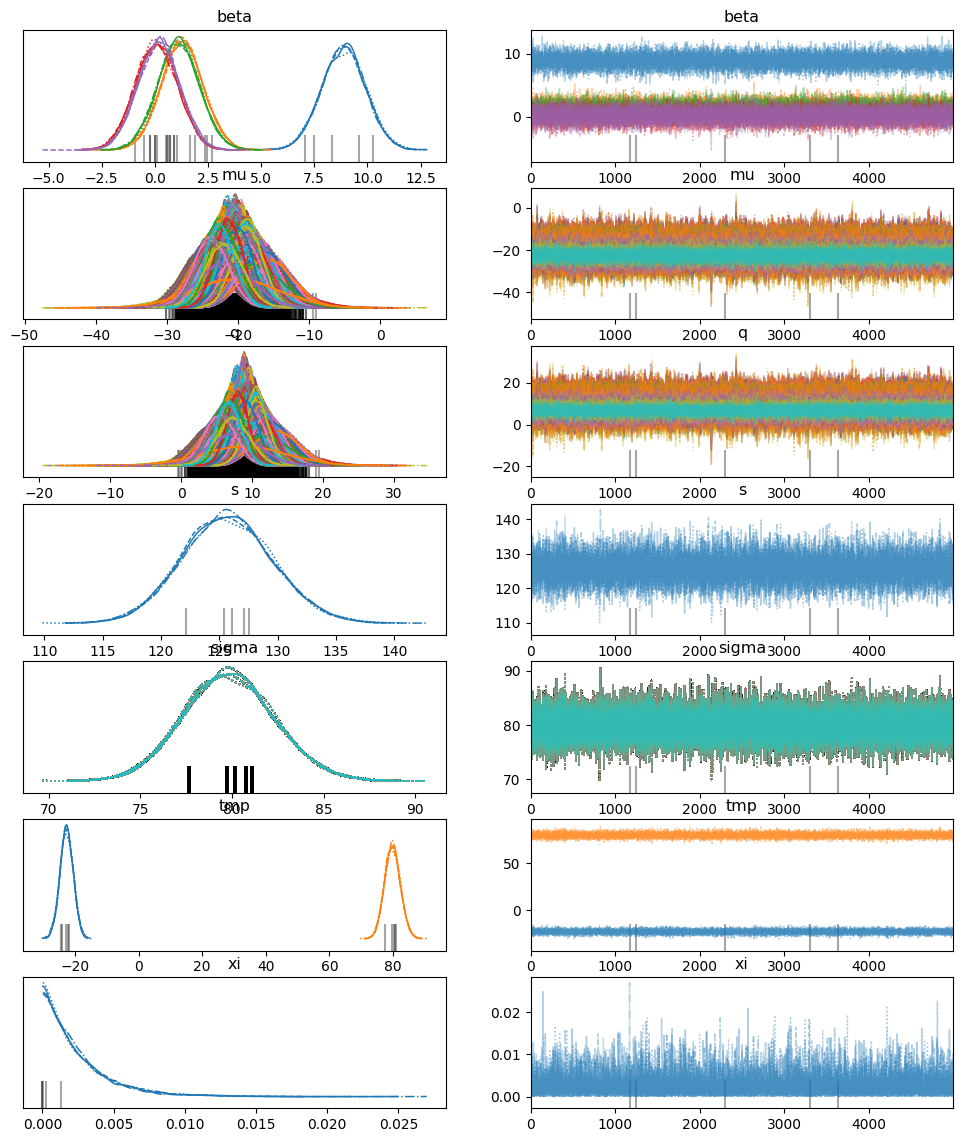

In [24]:
# Some plot using arviz
az.plot_trace(g_data)
plt.show()

/usr/local/lib/python3.12/dist-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (2799), generating only 20 plots
  warnings.warn(


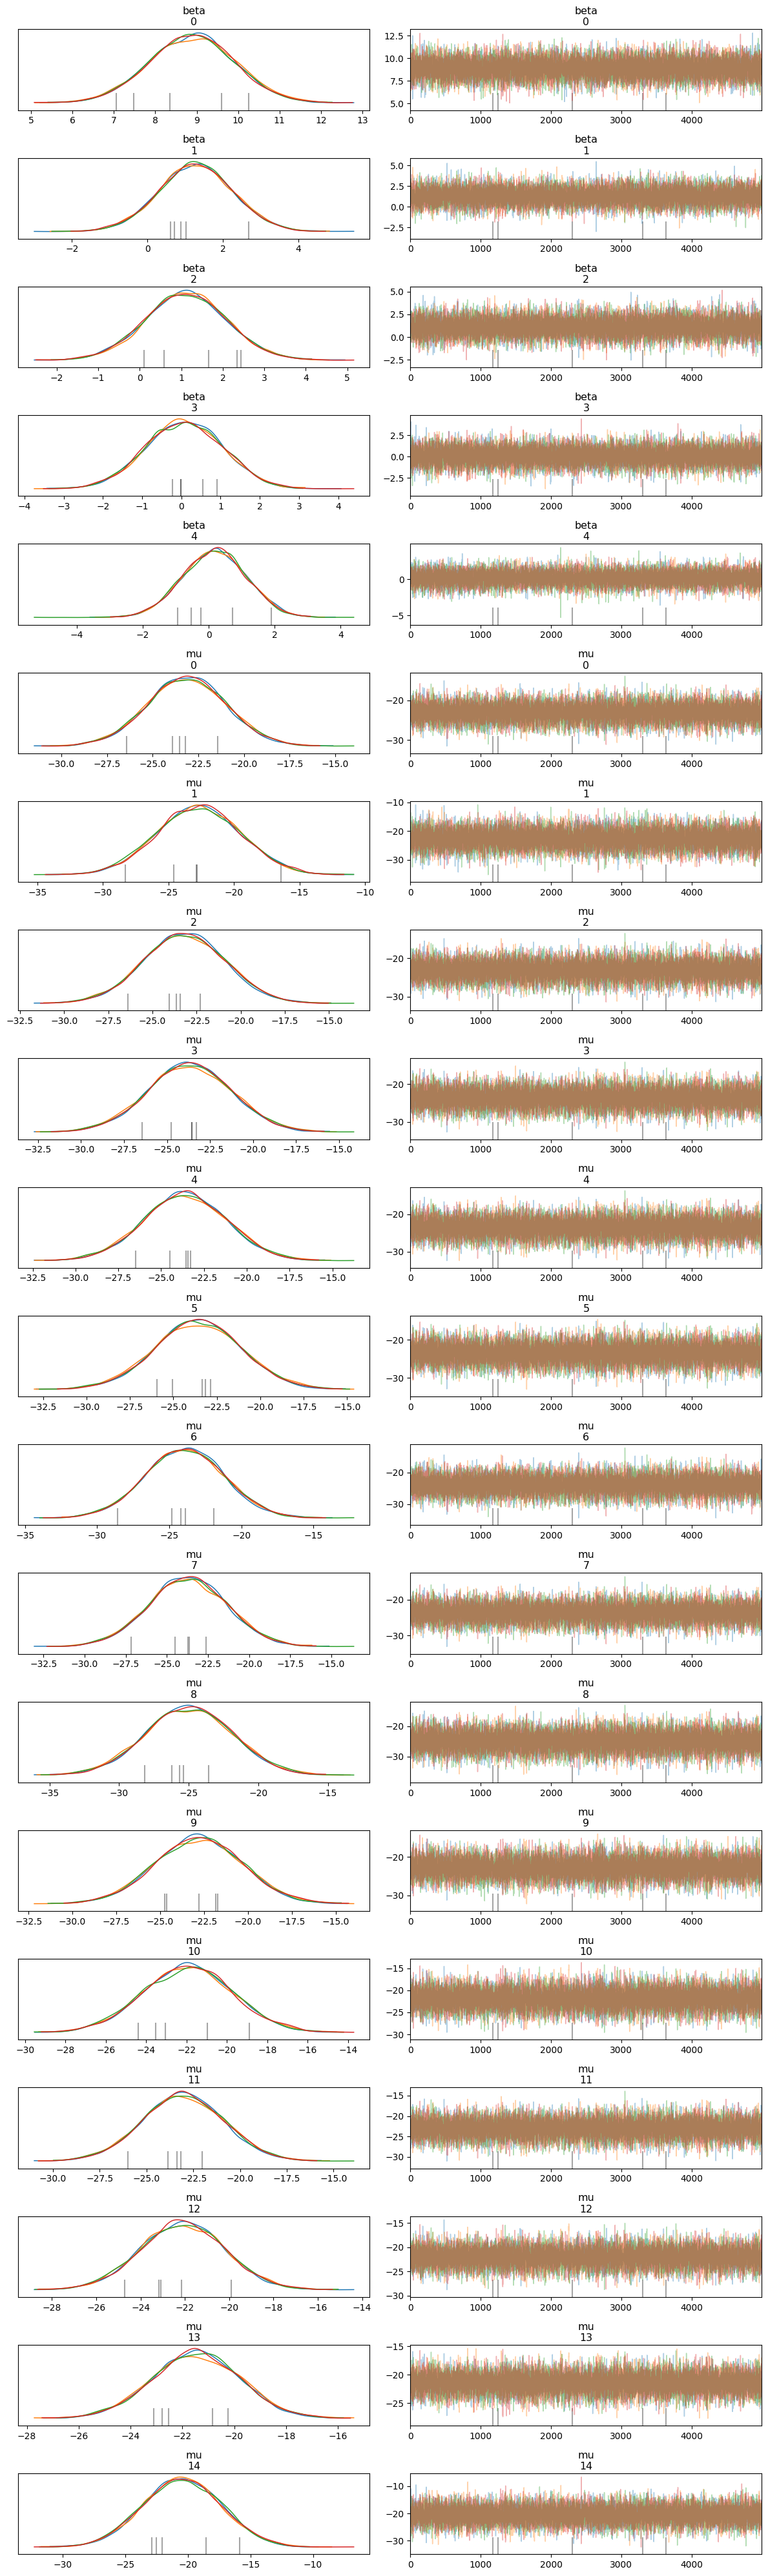

In [28]:
az.plot_trace(g_data, compact=False)
plt.tight_layout()
plt.show()

## Compare INLA and STAN

In [ ]:
# save g_data
import pickle

with open("./stan/g_data.pkl", "wb") as f:
    pickle.dump(g_data, f)

In [19]:
# summary statistics

stan_summary = az.summary(
    g_data,
    var_names=["beta", "s", "xi"],
    hdi_prob=0.95
)
stan_summary

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],8.885,1.030,6.790,10.831,0.007,0.007,23024.0,15609.0,1.0
beta[1],1.286,0.978,-0.686,3.163,0.006,0.007,24478.0,14325.0,1.0
beta[2],1.115,0.975,-0.825,3.019,0.006,0.007,23695.0,14470.0,1.0
beta[3],0.074,0.986,-1.868,1.965,0.006,0.008,26077.0,13680.0,1.0
beta[4],0.175,0.970,-1.719,2.049,0.006,0.008,27823.0,14162.0,1.0
s,125.699,3.911,118.110,133.366,0.026,0.029,23579.0,15036.0,1.0
xi,0.002,0.002,0.000,0.007,0.000,0.000,17471.0,9450.0,1.0


In [ ]:
# save stan summary
stan_summary.to_csv("stan_summary.csv")

In [20]:
# Extract samples
posterior = g_data.posterior

beta_samples = posterior["beta"].values.reshape(-1, 5)
xi_samples   = posterior["xi"].values.flatten()
s_samples    = posterior["s"].values.flatten()

# stack samples in dataframe
stan_samples = pd.DataFrame({
    "beta0": beta_samples[:,0],
    "beta1": beta_samples[:,1],
    "beta2": beta_samples[:,2],
    "beta3": beta_samples[:,3],
    "beta4": beta_samples[:,4],
    "s": s_samples,
    "xi": xi_samples
})
stan_samples.head()

,beta0,beta1,beta2,beta3,beta4,s,xi
0,8.750344,-0.325794,1.611455,0.606356,0.392302,124.60223,0.000276
1,8.749222,2.290089,0.436375,-0.661253,-0.395376,126.93601,0.008750
2,8.660561,0.088327,1.548059,0.960189,0.701159,121.93363,0.000244
3,8.761212,2.559610,0.901437,-0.854925,-0.436454,128.32765,0.000346
4,7.799594,1.581598,2.136208,4.080950,-0.577702,125.91226,0.001875


In [21]:
beta_samples.shape, xi_samples.shape

((20000, 5), (20000,))

In [22]:
# import INLA summaries

beta_inla  = np.load("beta_inla.npy")
hyper_inla = np.load("hyper_inla.npy")

# vertical stack beta_inla, hyper_inla
params_inla = np.vstack((beta_inla, hyper_inla))


# create summary dataframe with row name
inla_summary = pd.DataFrame(params_inla[:7,:], columns=["Mean", "Std", "2.5%", "50%", "97.5%"], index=["Intercept", "minTemp", "maxTemp", "windSpeed", "rainSum", "s", "xi"])

#

inla_summary

,Mean,Std,2.5%,50%,97.5%
Intercept,10.781813,0.980100,8.858386,10.779769,12.701153
minTemp,1.460686,0.981064,-0.464633,1.458641,3.381915
maxTemp,1.926194,0.979871,0.003217,1.924151,3.845085
windSpeed,3.323468,0.976212,1.407672,3.321433,5.235195
rainSum,-0.016311,0.981133,-1.941765,-0.018356,1.905053
s,59.657551,2.920858,54.120197,59.584158,65.569242
xi,0.002886,0.002515,0.000167,0.002174,0.009245


In [23]:
# Quantitative comparison table

delta_mean = stan_summary["mean"].values - inla_summary["Mean"].values
sd_ratio = stan_summary["sd"].values / inla_summary["Std"].values

delta_median = np.median(stan_samples, axis=0) - inla_summary["50%"].values

# dataframe with columns: Parameter,	Mean_INLA,	Mean_Stan,	ΔMean,	SD_INLA,	SD_Stan,	SD_ratio
df = pd.DataFrame({
    "Parameter": ["Intercept", "minTemp", "maxTemp", "windSpeed", "rainSum", "s", "xi"],
    "Mean_INLA": inla_summary["Mean"].values,
    "Mean_Stan": stan_summary["mean"].values,
    "delta_Mean": delta_mean,
    "Median_INLA": inla_summary["50%"].values,
    "Median_Stan": np.median(stan_samples, axis=0),
    "delta_Median": delta_median,
    "SD_INLA": inla_summary["Std"].values,
    "SD_Stan": stan_summary['sd'].values,
    "SD_ratio": sd_ratio
})
df



,Parameter,Mean_INLA,Mean_Stan,delta_Mean,Median_INLA,Median_Stan,delta_Median,SD_INLA,SD_Stan,SD_ratio
0,Intercept,10.781813,8.885,-1.896813,10.779769,8.897916,-1.881854,0.980100,1.030,1.050913
1,minTemp,1.460686,1.286,-0.174686,1.458641,1.284777,-0.173864,0.981064,0.978,0.996877
2,maxTemp,1.926194,1.115,-0.811194,1.924151,1.111321,-0.812830,0.979871,0.975,0.995029
3,windSpeed,3.323468,0.074,-3.249468,3.321433,0.072901,-3.248532,0.976212,0.986,1.010026
4,rainSum,-0.016311,0.175,0.191311,-0.018356,0.185741,0.204096,0.981133,0.970,0.988653
5,s,59.657551,125.699,66.041449,59.584158,125.639285,66.055127,2.920858,3.911,1.338990
6,xi,0.002886,0.002,-0.000886,0.002174,0.001697,-0.000477,0.002515,0.002,0.795072
